## Plotting data from different formats

earthkit-plots leverages the power of earthkit-data to make plotting data from various formats a completely equivalent process.

In this example, we will access the same GRIB dataset above from a NetCDF file, an xarray dataset, and NumPy arrays. In each case, plotting the data should give exactly the same result.

#### GRIB

The data used in this example comes from the [ERA5 monthly averaged data on single levels from 1940 to present](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-monthly-means?tab=overview) dataset in the Copernicus Climate Change Service Climate Data Store, where it is available in both GRIB and netCDF. Let's get the dataset in GRIB first:

In [1]:
import earthkit.data as ekd

era5_2t_grib = ekd.from_source("sample", "era5-monthly-mean-2t-199312.grib")

#### NetCDF

Now the exact same dataset in netCDF format:

In [2]:
era5_2t_nc = ekd.from_source("sample", "era5-monthly-mean-2t-199312.nc")

#### xarray

Using earthkit-data, we can easily convert our netCDF data to xarray with:

In [3]:
era5_2t_ds = era5_2t_nc.to_xarray()
era5_2t_ds

<xarray.Dataset> Size: 8MB
Dimensions:    (time: 1, latitude: 721, longitude: 1440)
Coordinates:
  * time       (time) datetime64[ns] 8B 1993-12-01
  * latitude   (latitude) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
Data variables:
    t2m        (time, latitude, longitude) float64 8MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    history:      2024-05-21 15:58:02 GMT by grib_to_netcdf-2.28.1: /opt/ecmw...

#### NumPy

Similarly, we are able to transform into NumPy arrays with `.to_numpy()`.

Since a NumPy array of values has no geographical information, we will also need to extract the latitude and longitude values by converting to a `FieldList` object and using the `geography` component.

Finally, NumPy arrays have no metadata attached to them. If we want automatic styles, unit conversion and metadata formatting, we should build a dictionary of the minimal metadata we need - in this case the units, name and time information.

In [4]:
from datetime import datetime

lats, lons = era5_2t_nc.to_fieldlist().geography.latlons()
era5_2t_arr = era5_2t_nc.to_numpy().squeeze()

metadata = {
    "units": "K",
    "long_name": "2 metre temperature",
    "time": datetime(1993, 12, 1),
}

#### Putting it all together

Now, let's plot data from all these different sources as subplots on a `Figure`. Notice that (with the slight exception of NumPy) we use exactly the same methods in exactly the same way for each source type.

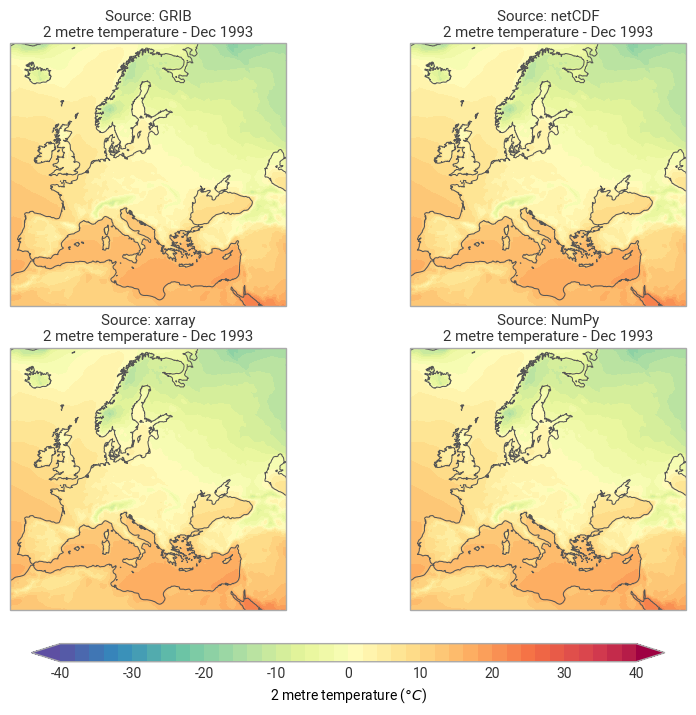

In [5]:
import earthkit.plots as ekp

fig = ekp.Figure(domain="Europe", rows=2, columns=2)

for fmt, data in zip (["GRIB", "netCDF", "xarray"], [era5_2t_grib, era5_2t_nc, era5_2t_ds]):
    subplot = fig.add_map()
    subplot.plot(data, units="celsius")
    subplot.title(f"Source: {fmt}\n{{variable_name}} - {{time:%b %Y}}")

# NumPy is slightly different as we need to manually pass the coordinates and metadata
subplot = fig.add_map()
subplot.plot(era5_2t_arr, x=lons, y=lats, metadata=metadata, units="celsius")
subplot.title("Source: NumPy\n{variable_name} - {time:%b %Y}")

fig.coastlines()
fig.legend()
    
fig.show()

### Conclusion

This example demonstrates that earthkit-plots promotes format-agnosticism when writing visualisation workflows. Creating maps follows the same approach from different sources like GRIB files, netCDF files, xarray datasets and NumPy arrays (which inevitably require a little more work!).